In [505]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [506]:
import torch
from torchvision import transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt
from darts_model import CNNTransformer, NUM_LABELS, NUM_QUERIES, match, loss_labels, loss_points
from score import fields, get_score
from darts_dataset import SyntheticDataset

In [507]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
query_dim = 256
model = CNNTransformer(d=query_dim).to(device)
model.load_state_dict(torch.load("models/epoch_280_0.0394_0.2686_0.9994_0.9915.pt", weights_only=True))

C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

In [509]:
transform = transforms.Compose([
    # transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
    transforms.Resize(300),  # ResNet-50 expects 224x224 images
    transforms.CenterCrop(300),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])

In [510]:
# _transform = transforms.Compose([
#     transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
#     transforms.Resize(224),  # ResNet-50 expects 224x224 images
#     transforms.CenterCrop(224),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
#                          std=[0.229, 0.224, 0.225])   # ImageNet std
# ])

In [511]:
# filename = "3D/data/imgs_std10_kind2_1/img_0055.png"
# filename="thommy/_IMG0827.jpg"
filename="my_unlabelled/vids/frames_0002/output_0088.jpg"

In [512]:
import os
DATA_DIRECTORY = "./3D/data"
LABELS_FILENAME = "combined.pkl"
LABELS_FILEPATH = os.path.join(DATA_DIRECTORY, LABELS_FILENAME)

In [513]:
dataset = SyntheticDataset(DATA_DIRECTORY, LABELS_FILEPATH)

           img_folder      img_name  \
0  imgs_std10_kind0_0  img_0000.png   
1  imgs_std10_kind0_0  img_0001.png   
2  imgs_std10_kind0_0  img_0002.png   
3  imgs_std10_kind0_0  img_0003.png   
4  imgs_std10_kind0_0  img_0004.png   

                                                  xy  
0  [[0.4519217014312744, 0.1922926902770996], [0....  
1  [[0.5078747272491455, 0.08181816339492798], [0...  
2  [[0.4471089839935303, 0.0990215539932251], [0....  
3  [[0.45292484760284424, 0.2456604242324829], [0...  
4  [[0.4670245945453644, 0.2610541582107544], [0....  


In [514]:
image = transforms.ToTensor()(cv2.imread(filename, cv2.IMREAD_COLOR_RGB))
idx = np.random.randint(len(dataset))
# image, targets = dataset[idx]
image_transformed = transform(image)

In [515]:
from itertools import combinations
from scipy.spatial.distance import cdist

In [516]:
def max_sum_pairwise_dist(X, k):
    """Find k vectors with the maximum sum of pairwise distances"""
    n = X.shape[0]
    X = X.cpu().detach()
    distance_matrix = cdist(X, X)
    
    best_subset = None
    max_distance = -np.inf
    
    # Check all possible combinations of k points
    for subset in combinations(range(n), k):
        total_distance = np.sum([distance_matrix[i, j] for i, j in combinations(subset, 2)])
        if total_distance > max_distance:
            max_distance = total_distance
            best_subset = subset
    
    return best_subset

torch.Size([5, 256]) [0, 1, 4] tensor([16, 12, 48]) tensor([48,  8, 16])
tensor([3], device='cuda:0')


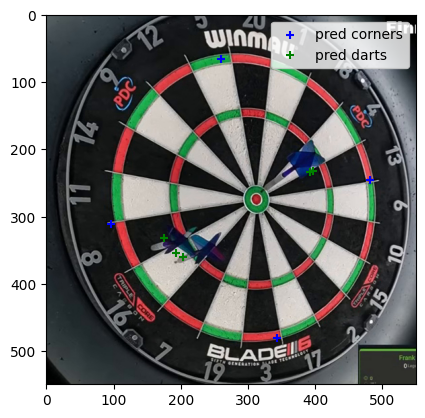

In [517]:
model.eval()
# targets = {k: v.to(device) for k, v in targets.items()}
_, w, h = image.shape  
images = image_transformed.unsqueeze(0).to(device) 
outputs = model(images)
decoder_layer=-1
# print(targets["score"])
# indices = match(outputs, [targets], decoder_layer)
# print(indices)

pred_confidence, pred_classes = torch.max(outputs["logits"][decoder_layer, 0].softmax(-1).cpu(), dim=-1)
# pred_confidence = pred_confidence[pred_classes != NUM_LABELS-1]
thresh = 0.50
pred_fields = torch.as_tensor([-2,-3,-4,-5] + fields + [-1])[pred_classes]#[pred_classes != len(fields)][pred_confidence > thresh]

# pred_confidence = pred_confidence[pred_confidence > 0.7]
# pred_fields = pred_fields[pred_confidence > 0.95]
# pred_confidence = pred_confidence[pred_confidence > 0.95]
num_darts = outputs["logits_num_darts"].argmax(-1)
darts_conf = pred_confidence[pred_fields > -1]
# print(pred_fields[pred_classes != NUM_LABELS-1][ pred_confidence.argsort(-1)[-4-num_darts:]])
dart_queries = outputs["out_queries"][decoder_layer, 0][pred_fields > -1][darts_conf > thresh]
selected_darts = list(max_sum_pairwise_dist(dart_queries, num_darts))
pred_darts = pred_fields[pred_fields > -1][darts_conf > thresh]
print(dart_queries.shape, selected_darts, pred_darts[selected_darts], pred_fields[pred_fields > -1][darts_conf.argsort(-1)[-num_darts:]])
print(num_darts)

# print(pred_confidence)
# print(outputs["logits"][-1, 0][pred_classes])
fig, ax = plt.subplots(1)
ax.imshow(image.permute(1,2,0))
# print(np.array([-2,-3,-4,-5] + fields + [-1])[targets["labels"][indices[0][1]].cpu()], outputs["logits"][decoder_layer, 0].softmax(-1)[indices[0]])
# print(loss_labels(outputs, [targets], indices, decoder_layer))
pred_corners = outputs["points"][decoder_layer, 0][pred_fields< -1].cpu().detach()
pred_darts = outputs["points"][decoder_layer, 0][pred_fields > -1][darts_conf > thresh].cpu().detach()
all_points = outputs["points"][decoder_layer, 0].cpu().detach()
# Draw points
# ax.scatter(all_points[:, 0]*w, all_points[:, 1]*h, color='white', s=10, marker='x', label="all darts")
# ax.scatter(all_points[indices[0][0]][:, 0]*w, all_points[indices[0][0]][:, 1]*h, color='yellow', s=40, marker='o', label="targets")
ax.scatter(pred_corners[:, 0]*w, pred_corners[:, 1]*h, color='blue', s=40, marker='+', label="pred corners")
ax.scatter(pred_darts[:, 0]*w, pred_darts[:, 1]*h, color='green', s=40, marker='+', label="pred darts")
# ax.scatter(targets["points"][:, 0].cpu()*w, targets["points"][:, 1].cpu()*h, color='yellow', s=40, marker='o', label="targets")

# Show plot
plt.legend()
plt.show()